# 01 - Exploratory Data Analysis
Load the retail dataset, inspect columns, missing values, distributions, and time-based patterns.

In [3]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('../data/raw/retail_store_inventory.csv')


In [4]:
def check_df(dataframe, head= 5):
    print("############### HEAD #################")
    print(dataframe.head())
    print("############### TAIL #################")
    print(dataframe.tail())
    #print("############### QUANTILE #################")
    #print(dataframe.quantiles([0.25, 0.5, 0.75]))
    print("############### MISSING VALUE #################")
    print(dataframe.isnull().sum())
    print("############### TYPES #################")
    print(dataframe.dtypes)
    print("############### SHAPE #################")
    print(dataframe.shape)
    print("############### DESCRIBE #################")
    print(dataframe.describe())

In [5]:
check_df(df, 5)
# Date     object

############### HEAD #################
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0        

In [7]:
num_cols = [col for col in df.columns if df[col].dtypes != 'object']
num_cols

cat_cols = [col for col in df.columns if( df[col].dtypes == 'object')  ]
cat_cols

['Date',
 'Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Seasonality']

In [8]:
for col in cat_cols:
    print("############### COLUMN: {} #################".format(col))
    print(df[col].value_counts())
    print("########### UNIQUE VALUES #############")
    print(df[col].nunique())

############### COLUMN: Date #################
2023-03-21    100
2022-06-30    100
2022-03-19    100
2023-01-19    100
2022-10-11    100
             ... 
2022-10-21    100
2022-11-13    100
2023-04-27    100
2022-04-14    100
2022-07-20    100
Name: Date, Length: 731, dtype: int64
########### UNIQUE VALUES #############
731
############### COLUMN: Store ID #################
S005    14620
S004    14620
S001    14620
S002    14620
S003    14620
Name: Store ID, dtype: int64
########### UNIQUE VALUES #############
5
############### COLUMN: Product ID #################
P0002    3655
P0004    3655
P0017    3655
P0005    3655
P0003    3655
P0019    3655
P0008    3655
P0006    3655
P0015    3655
P0007    3655
P0013    3655
P0018    3655
P0020    3655
P0010    3655
P0009    3655
P0016    3655
P0001    3655
P0012    3655
P0011    3655
P0014    3655
Name: Product ID, dtype: int64
########### UNIQUE VALUES #############
20
############### COLUMN: Category #################
Furniture      14699
To

In [9]:
print(df['Date'].max())

print(df['Date'].min())

2024-01-01
2022-01-01


In [ ]:
df.groupby('Store ID').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})


Units Sold                             
                           sum    mean  max min         std
Date       Store ID                                        
2022-01-01 S001           2762  138.10  369  12  103.928569
           S002           2974  148.70  393   9  123.366847
           S003           3208  160.40  370   4  125.827953
           S004           2505  125.25  382   0  111.155119
           S005           3035  151.75  371   8  108.634043
...                        ...     ...  ...  ..         ...
2024-01-01 S001           2278  113.90  272   9   92.023395
           S002           2264  113.20  347   2  107.349209
           S003           3067  153.35  398   9  112.640684
           S004           2543  127.15  496   1  127.996001
           S005           3092  154.60  324   4  106.299676

[3655 rows x 5 columns]

In [64]:
df.groupby('Product ID').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                  sum        mean  max min         std
Product ID                                            
P0001          498061  136.268399  496   0  109.315675
P0002          487827  133.468399  486   0  106.417492
P0003          493279  134.960055  485   0  108.380437
P0004          495501  135.567989  489   0  109.263223
P0005          503648  137.796990  488   0  106.854998
P0006          497131  136.013953  489   0  108.807250
P0007          499321  136.613133  491   0  110.505351
P0008          488563  133.669767  494   0  108.675121
P0009          502086  137.369631  491   0  110.560806
P0010          496469  135.832832  488   0  109.721355
P0011          499362  136.624350  484   0  108.245989
P0012          491670  134.519836  496   0  107.748105
P0013          500619  136.968263  494   0  108.149168
P0014          507622  138.884268  485   0  110.203837
P0015          507283  138.791518  482   0  109.914956
P0016          508472  139.116826  492   0  109.389823
P0017          500510  136.938440  495   0  107.890733
P0018          492551  134.760876  499   0  108.535957
P0019          497899  136.224077  479   0  109.493124
P0020          507708  138.907798  484   0  110.229782

In [65]:
df.groupby('Category').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                   sum        mean  max min         std
Category                                               
Clothing       1999166  136.685765  489   0  108.421855
Electronics    1960432  135.006680  496   0  108.448033
Furniture      2025017  137.765630  499   0  110.017747
Groceries      2000482  136.916159  494   0  109.256043
Toys           1990485  135.934235  496   0  108.431014

In [66]:
df.groupby('Weather Condition').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                         sum        mean  max min         std
Weather Condition                                            
Cloudy               2497207  136.758324  495   0  108.328539
Rainy                2470455  135.160028  487   0  107.919441
Snowy                2483376  135.911559  499   0  109.379042
Sunny                2524544  138.028650  494   0  110.024762

In [67]:
df.groupby('Region').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
              sum        mean  max min         std
Region                                            
East      2511265  136.861137  499   0  109.473085
North     2484966  136.326860  491   0  109.207022
South     2507799  137.060666  489   0  108.959817
West      2471552  135.605838  496   0  108.031480

In [68]:
df.groupby(['Store ID', 'Product ID']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                           sum        mean  max min         std
Store ID Product ID                                            
S001     P0001          100371  137.306430  461   0  108.187859
         P0002           95789  131.038304  486   0  104.313220
         P0003          103393  141.440492  484   0  107.211225
         P0004          103001  140.904241  475   0  113.644117
         P0005           97318  133.129959  480   0  107.368873
...                        ...         ...  ...  ..         ...
S005     P0016          101821  139.290014  480   0  111.576662
         P0017          100358  137.288646  484   0  108.617275
         P0018           98064  134.150479  487   0  109.795997
         P0019           98724  135.053352  474   0  108.657996
         P0020          101370  138.673051  484   0  111.140716

[100 rows x 5 columns]

In [69]:
df.groupby(['Holiday/Promotion']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                         sum        mean  max min         std
Holiday/Promotion                                            
0                    5016163  136.505375  499   0  109.276450
1                    4959419  136.423926  496   0  108.558786

In [70]:

df.groupby(['Date', 'Store ID']).agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                             
                           sum    mean  max min         std
Date       Store ID                                        
2022-01-01 S001           2762  138.10  369  12  103.928569
           S002           2974  148.70  393   9  123.366847
           S003           3208  160.40  370   4  125.827953
           S004           2505  125.25  382   0  111.155119
           S005           3035  151.75  371   8  108.634043
...                        ...     ...  ...  ..         ...
2024-01-01 S001           2278  113.90  272   9   92.023395
           S002           2264  113.20  347   2  107.349209
           S003           3067  153.35  398   9  112.640684
           S004           2543  127.15  496   1  127.996001
           S005           3092  154.60  324   4  106.299676

[3655 rows x 5 columns]

In [63]:
df.groupby("Month").agg({"Seasonality": "value_counts"})

# Seasonlity feature'ı Month'dan bağımsızdır. Tüm aylar için Seasonality 
# feature'ı aynı değeri alıyor. Bu nedenle, Month ve Seasonality feature'ları 
# arasında bir bağımlılık var. 

Seasonality
Month Seasonality             
1     Winter              1599
      Autumn              1574
      Spring              1565
      Summer              1562
2     Summer              1464
      Autumn              1439
      Winter              1379
      Spring              1318
3     Spring              1597
      Summer              1563
      Winter              1523
      Autumn              1517
4     Spring              1561
      Autumn              1496
      Winter              1496
      Summer              1447
5     Autumn              1579
      Winter              1562
      Spring              1533
      Summer              1526
6     Spring              1522
      Summer              1518
      Autumn              1496
      Winter              1464
7     Summer              1596
      Autumn              1540
      Winter              1539
      Spring              1525
8     Winter              1675
      Summer              1560
      Spring              1487
      Autumn              1478
9     Spring              1535
      Autumn              1506
      Summer              1505
      Winter              1454
10    Spring              1578
      Summer              1578
      Winter              1542
      Autumn              1502
11    Winter              1517
      Autumn              1500
      Spring              1500
      Summer              1483
12    Spring              1596
      Autumn              1566
      Winter              1535
      Summer              1503

In [75]:
df.groupby(['Store ID']).agg({'Seasonality': 'value_counts'})

Seasonality
Store ID Seasonality             
S001     Winter              3700
         Summer              3681
         Autumn              3627
         Spring              3612
S002     Spring              3690
         Summer              3654
         Winter              3653
         Autumn              3623
S003     Spring              3683
         Autumn              3652
         Winter              3643
         Summer              3642
S004     Summer              3708
         Winter              3667
         Spring              3662
         Autumn              3583
S005     Autumn              3708
         Spring              3670
         Winter              3622
         Summer              3620

In [76]:
df.groupby(['Product ID']).agg({'Seasonality': 'value_counts'})

Seasonality
Product ID Seasonality             
P0001      Spring               933
           Summer               913
           Winter               907
           Autumn               902
P0002      Summer               923
...                             ...
P0019      Winter               890
P0020      Autumn               934
           Spring               916
           Summer               913
           Winter               892

[80 rows x 1 columns]

In [ ]:
df.groupby(['Region']).agg({'Seasonality': 'value_counts'})

Seasonality
Region Seasonality             
East   Summer              4664
       Winter              4595
       Autumn              4583
       Spring              4507
North  Spring              4626
       Autumn              4558
       Summer              4553
       Winter              4491
South  Winter              4658
       Spring              4592
       Summer              4567
       Autumn              4480
West   Spring              4592
       Autumn              4572
       Winter              4541
       Summer              4521

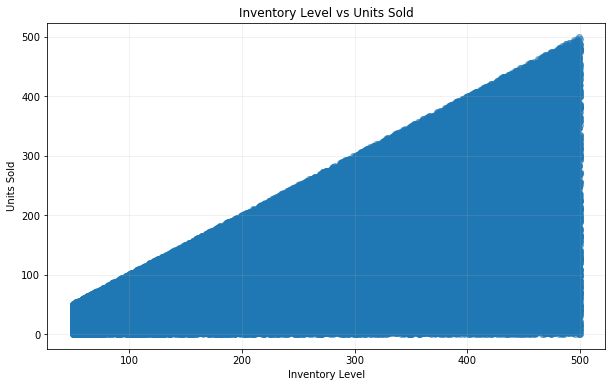

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Inventory Level"],
    df["Units Sold"],
    alpha=0.5
)

plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.title("Inventory Level vs Units Sold")

plt.grid(alpha=0.2)
plt.show()

In [14]:
num_cols

['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Demand Forecast',
 'Price',
 'Discount',
 'Holiday/Promotion',
 'Competitor Pricing']

In [ ]:
def check_outliers(dataframe, col_name, q1=0.25, q3=0.75):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [16]:
for col in num_cols:
    if check_outliers(df, col):
        print(col, "has outliers")
    else:
        print(col, "does not have outliers")

Inventory Level does not have outliers
Units Sold has outliers
Units Ordered does not have outliers
Demand Forecast has outliers
Price does not have outliers
Discount does not have outliers
Holiday/Promotion does not have outliers
Competitor Pricing does not have outliers


In [26]:
df_zero = df[df["Units Sold"] == 0]
df_zero

# Zero units sold olan store ID'leri say
df_zero["Store ID"].value_counts()

# Zero units sold olan product ID'leri say
df_zero["Product ID"].value_counts()

P0019    25
P0018    24
P0010    24
P0004    24
P0015    24
P0020    20
P0014    20
P0007    20
P0017    19
P0001    18
P0006    16
P0016    16
P0008    16
P0013    16
P0002    15
P0011    15
P0012    13
P0003    13
P0005    12
P0009    10
Name: Product ID, dtype: int64

In [50]:
# Seasonality gerçekten doğru mu, check et
from datetime import datetime

"""
df["Date"].dtypes
df['Date'] = df['Date'].astype('datetime64[ns]')
df["Month"] = df["Date"].dt.month
"""

df["Seasonality_NEW"] = df["Date"].apply(lambda x: "Winter" if x.month in [12, 1, 2] else ("Spring" if x.month in [3, 4, 5] else ("Summer" if x.month in [6, 7, 8] else "Fall")))

In [ ]:
df["Seasonality_NEW"].value_counts()


Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: Seasonality, dtype: int64

In [54]:
df["Seasonality"].value_counts()

Spring    18317
Summer    18305
Winter    18285
Autumn    18193
Name: Seasonality, dtype: int64

In [ ]:
df.groupby("Month").agg({"Seasonality": "value_counts"})

# Seasonlity feature'ı Month'dan bağımsızdır. Tüm aylar için Seasonality 
# feature'ı aynı değeri alıyor. Bu nedenle, Month ve Seasonality feature'ları 
# arasında bir bağımlılık var. 

Seasonality
Month Seasonality             
1     Winter              1599
      Autumn              1574
      Spring              1565
      Summer              1562
2     Summer              1464
      Autumn              1439
      Winter              1379
      Spring              1318
3     Spring              1597
      Summer              1563
      Winter              1523
      Autumn              1517
4     Spring              1561
      Autumn              1496
      Winter              1496
      Summer              1447
5     Autumn              1579
      Winter              1562
      Spring              1533
      Summer              1526
6     Spring              1522
      Summer              1518
      Autumn              1496
      Winter              1464
7     Summer              1596
      Autumn              1540
      Winter              1539
      Spring              1525
8     Winter              1675
      Summer              1560
      Spring              1487
      Autumn              1478
9     Spring              1535
      Autumn              1506
      Summer              1505
      Winter              1454
10    Spring              1578
      Summer              1578
      Winter              1542
      Autumn              1502
11    Winter              1517
      Autumn              1500
      Spring              1500
      Summer              1483
12    Spring              1596
      Autumn              1566
      Winter              1535
      Summer              1503

In [84]:
df['DayOfWeek'] = df['Date'].dt.day_name()

df.groupby('DayOfWeek').agg({'Units Sold': ['sum', 'mean', 'max', 'min', 'std']})

Units Sold                                 
                 sum        mean  max min         std
DayOfWeek                                            
Friday       1423255  136.851442  499   0  109.325385
Monday       1418494  135.094667  496   0  107.565373
Saturday     1420802  135.314476  495   0  109.010161
Sunday       1436502  136.809714  493   0  109.364674
Thursday     1427732  137.281923  494   0  108.706532
Tuesday      1428000  137.307692  494   0  109.464466
Wednesday    1420797  136.615096  485   0  109.004222

mkl-random 1.0.1 requires cython, which is not installed.
tensorflow 1.10.0 has requirement numpy<=1.14.5,>=1.13.3, but you'll have numpy 1.19.5 which is incompatible.
tensorflow 1.10.0 has requirement setuptools<=39.1.0, but you'll have setuptools 58.0.4 which is incompatible.
You are using pip version 10.0.1, however version 21.3.1 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


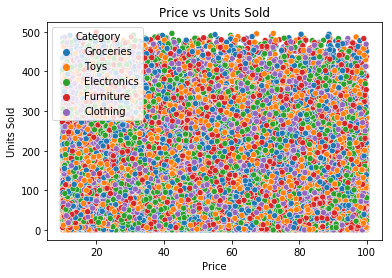

In [82]:
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(data=df, x='Price', y='Units Sold', hue='Category')
plt.title("Price vs Units Sold")
plt.show()

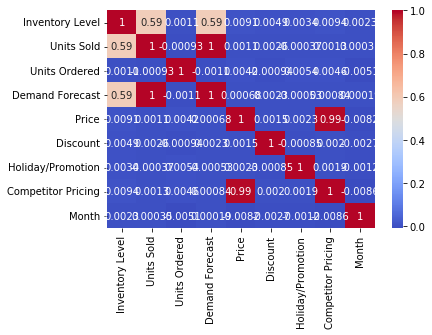

In [83]:
# Correlation matrix
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [85]:
# Lag correlation
pd.DataFrame({"Units Sold": df["Units Sold"].values[0:10],
              "lag1": df["Units Sold"].shift(1).values[0:10],
              "lag2": df["Units Sold"].shift(2).values[0:10],
              "lag3": df["Units Sold"].shift(3).values[0:10],
              "lag4": df["Units Sold"].shift(4).values[0:10]})

,Units Sold,lag1,lag2,lag3,lag4
0,127,NaN,NaN,NaN,NaN
1,150,127.0,NaN,NaN,NaN
2,65,150.0,127.0,NaN,NaN
3,61,65.0,150.0,127.0,NaN
4,14,61.0,65.0,150.0,127.0
5,128,14.0,61.0,65.0,150.0
6,97,128.0,14.0,61.0,65.0
7,312,97.0,128.0,14.0,61.0
8,175,312.0,97.0,128.0,14.0
9,28,175.0,312.0,97.0,128.0


In [ ]:
# Ürünün x gün önce kaç birim satıldığı bilgisidir.
def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['units_sold_lag_' + str(lag)] = dataframe.groupby(["Store ID", "Product ID"])['Units Sold'].transform(
            lambda x: x.shift(lag)) 
    return dataframe

df = lag_features(df, [1, 2, 3, 7, 14, 30, 365])

In [ ]:
# Ürünün bugünden önceki x gün boyunca günde ortalama kaç adet satıldığı bilgisidir
# Rolling statistics
def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['sales_roll_mean_' + str(window)] = (
            dataframe.groupby(["Store ID", "Product ID"])['Units Sold']
            .transform(lambda x: x.shift(1).rolling(window=window).mean())
        )
    return dataframe

# burada shift(1) kullanmamızın sebebi, o günün satışını tahmin etmek 
# için o günün satışını kullanamayız. Bu nedenle, bir önceki günün satışını 
# kullanıyoruz.


In [107]:
df = roll_mean_features(df, [7, 30])

In [111]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,DayOfWeek,units_sold_lag_1,units_sold_lag_2,units_sold_lag_3,units_sold_lag_7,units_sold_lag_14,units_sold_lag_30,units_sold_lag_365,sales_roll_mean_7,sales_roll_mean_30
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,...,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,...,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,...,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,...,Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,...,Monday,54.0,11.0,273.0,43.0,230.0,340.0,7.0,87.571429,146.833333
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,...,Monday,162.0,150.0,225.0,119.0,288.0,205.0,3.0,135.000000,129.700000
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,...,Monday,111.0,29.0,144.0,5.0,54.0,65.0,74.0,95.428571,104.033333
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,...,Monday,17.0,29.0,80.0,213.0,271.0,214.0,19.0,137.142857,144.900000


In [ ]:
"""
# ------------------------------------------------------------
# 1. VERİ SETİ GENEL DURUM
# ------------------------------------------------------------
# - 73.100 satır, 15 sütun | 2022-01-01 - 2024-01-01 (731 gün)
# - 5 Mağaza x 20 Ürün x 731 gün = tam dengeli panel veri (dengesizlik yok)
# - Eksik değer (null) YOK
# - Veri büyük ihtimalle SENTETİK üretilmiş (Kaggle "Retail Store
#   Inventory Forecasting" veri seti ile örtüşüyor) -> bu yüzden birçok
#   business ilişkisi (fiyat, kampanya vb.) veride gerçekten YOK,
#   bunu modelden beklememek gerekiyor

# ------------------------------------------------------------
# 2. KRİTİK EDA BULGULARI
# ------------------------------------------------------------

# 🔴 BULGU 1 - "Demand Forecast" = TARGET LEAKAGE (EN ÖNEMLİ BULGU)
# Units Sold ile Demand Forecast arasındaki korelasyon = 1.00
# Bu kolon muhtemelen Units Sold + küçük gürültü ile üretilmiş.
# Feature olarak kullanılırsa model "cevabı" görmüş olur.
# AKSİYON: Bu kolonu feature setinden ÇIKAR.
#          Sadece "naif baseline" olarak sakla -> kendi modelini
#          bu kolonla kıyaslayarak ne kadar iyileştirme sağladığını göster.

# 🔴 BULGU 2 - Inventory Level, Units Sold'u FİİLEN KISITLIYOR
# Scatter plot üçgen şeklinde: Units Sold hep Inventory Level'ın altında
# kalıyor (neredeyse Units Sold ~ Uniform(0, Inventory Level) gibi).
# Korelasyon = 0.59 (orta-güçlü, göz ardı edilemez)
# AKSİYON: Inventory Level'ı güçlü bir feature olarak tut, üzerine
#          ek feature'lar türet (örn. stok/talep oranı gibi).

# 🟡 BULGU 3 - Fiyat/Kampanya/Hava Durumu/Bölge -> Units Sold ile
# neredeyse SIFIR korelasyon (0.001-0.003 aralığında).
# Promosyonlu/promosyonsuz günlerin ortalama satışı da aynı (~136).
# AKSİYON: Bu feature'ları yine de modele koy (ağaç modelleri gürültülü
#          feature'lardan fazla zarar görmez) ama business hikayesinde
#          ("indirim talebi artırır" gibi) abartılı iddialarda bulunma -
#          veri bunu desteklemiyor, sunumda dürüstçe belirt.

# 🟡 BULGU 4 - Price ile Competitor Pricing neredeyse birebir aynı
# (korelasyon = 0.99) -> multicollinearity riski
# AKSİYON: İkisini ham haliyle birlikte kullanmak yerine
#          Price_Diff / Price_Ratio gibi TEK bir türetilmiş feature'a indir

# 🔴 BULGU 5 - Orijinal "Seasonality" kolonu BOZUK / rastgele
# Ay bazında kırılımda (örn. Ocak ayı) dört mevsim de birbirine yakın
# sayıda görünüyor -> gerçek bir mevsim kolonu olsaydı Ocak ağırlıklı
# "Winter" olurdu. Muhtemelen tarihten bağımsız, rastgele atanmış.
# NOT: Toplam value_counts'ların eşleşmesi (Seasonality vs
# Seasonality_NEW) YETERLİ KANIT DEĞİL - satır bazlı kontrol
# (df["Seasonality"] == df["Seasonality_NEW"]).mean() ile doğrulanmalı.
# AKSİYON: Orijinal Seasonality kolonunu SİL, tarihten yeniden türet.

# 🟡 BULGU 6 - Demand Forecast'ta minimum -9.99 (negatif talep anomalisi)
# AKSİYON: np.maximum(0, df['Demand Forecast']) ile düzelt
#          (yalnızca baseline karşılaştırması için saklanıyorsa bile
#          düzeltilmiş olması gerekir)

# 🟠 BULGU 7 - Notebook reprodüksiyon sorunları (teknik borç)
# - Date -> datetime dönüşümü bir hücrede docstring içinde kalmış,
#   hiç çalıştırılmamış; ama sonraki hücrelerde .dt erişimi kullanılmış
#   (kernel state'e güvenilmiş, sıfırdan çalıştırılırsa hata verir)
# - roll_mean_features fonksiyonunda çözülmemiş bir ValueError var
#   (min_periods 10 must be <= window 7)
# AKSİYON: Notebook'u temiz bir kernel ile baştan sona çalıştırıp
#          doğrula, tüm dönüşümleri açık hücrelere taşı

# ------------------------------------------------------------
# 3. PREPROCESSING - YAPILACAKLAR
# ------------------------------------------------------------

# [ ] Date sütununu datetime'a çevir (kalıcı, açık bir hücrede)
# [ ] Demand Forecast negatif değerlerini 0'a çek (np.maximum)
# [ ] Demand Forecast'ı FEATURE SETİNDEN ÇIKAR (leakage) - sadece
#     baseline karşılaştırma için ayrı bir kolonda sakla
# [ ] Orijinal Seasonality kolonunu SİL

# ------------------------------------------------------------
# 4. FEATURE ENGINEERING - YAPILACAKLAR
# ------------------------------------------------------------

# --- Zaman bazlı feature'lar ---
# [ ] Year, Month, Day, DayOfWeek, Is_Weekend
# [ ] Seasonality_NEW: gerçek aya göre türet
#     (Winter: 12-1-2, Spring: 3-4-5, Summer: 6-7-8, Autumn: 9-10-11)

# --- Lag / Rolling feature'lar (Store ID + Product ID bazında groupby) ---
# [ ] Lag_1, Lag_7, Lag_14, Lag_30, Lag_365
# [ ] sales_roll_mean_7, sales_roll_mean_30, sales_roll_std_7
#     -> shift(1) ile hesapla (bugünün verisini kullanma, leakage olur)
# NOT: Lag_365 ilk 365 gün için NaN üretecek (~%36-40 satır) - veri
# sadece 2 yıllık olduğu için kaçınılmaz. XGBoost/LightGBM NaN'ı
# native tolere eder, satırları silmeye gerek YOK.

# --- Stok bazlı feature'lar (Bulgu 2'den dolayı eklendi) ---
# [ ] Inventory Level'ı olduğu gibi tut (güçlü sinyal)
# [ ] Stok/talep tahmini oranı gibi türetilmiş feature'lar denenebilir

# --- Fiyat / rekabet feature'ları ---
# [ ] Net_Price = Price * (1 - Discount/100)
# [ ] Price_Diff_vs_Competitor = Price - Competitor Pricing
# [ ] Price_Ratio = Price / Competitor Pricing
# [ ] Discount_Flag = (Discount > 0).astype(int)
# NOT: Price ile Competitor Pricing birlikte ham haliyle KULLANMA
# (corr=0.99, multicollinearity)

# --- Encoding ---
# [ ] Weather Condition, Region, Seasonality_NEW -> One-Hot Encoding
# [ ] Store ID (5), Product ID (20), Category (5) -> bunlar gerçekte
#     high-cardinality DEĞİL. Target encoding gereksiz leakage riski
#     taşır (zaman serisinde out-of-fold yapılmazsa). Basit tut:
#     Label Encoding veya ağaç modelleri için native categorical yeterli.

# ------------------------------------------------------------
# 5. MODEL VALIDATION STRATEJİSİ
# ------------------------------------------------------------
# [ ] Random split KULLANMA (zaman serisi yapısını bozar)
# [ ] Tarih sırasına göre son 14-30 gün -> Test seti (hold-out)
#     öncesi -> Train seti
# [ ] Model performansını Demand Forecast (naif baseline) ile
#     kıyaslayarak raporla (MAE / RMSE farkı)
"""